# Cryptocurrency Exploratory Data Analysis (EDA)

## Introduction
This notebook provides a visual analysis of historical cryptocurrency price data. The goal is to understand the behavior, risk, and return characteristics of major cryptocurrencies over the past year. This analysis supports investment decision-making by clarifying volatility and growth potential without making predictions.

**Dataset**: `historical_prices.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
file_path = 'historical_prices.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    df = pd.DataFrame()

# Data Cleaning Function
# The dataset contains raw Series string representations in price columns.
# We extract the numerical value using regex.
def clean_price_value(x):
    if pd.isna(x):
        return None
    # If it's already a number, return it
    if isinstance(x, (int, float)):
        return float(x)
    # Convert to string and search for the first float number
    s = str(x)
    # Match optional sign, digits, dot, digits
    match = re.search(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', s)
    if match:
        # Check if the match is just a row index number or the actual price
        # The string format is typically: "Ticker\nSYMBOL    PRICE\nName..."
        # The regex finds the first number. If the symbol is BTC-USD, the price is the first number after the symbol.
        # Let's simple split by whitespace and find the first purely numeric token that looks like a price.
        # A more robust regex specific to the observed format:
        lines = s.split('\n')
        for line in lines:
            parts = line.split()
            if len(parts) >= 2:
                # Try the second part (value) if the first part is Ticker-like
                try:
                    return float(parts[1])
                except ValueError:
                    continue
        # Fallback to simple regex if structure fails
        return float(match.group(1))
    return None

if not df.empty:
    # Clean 'close' column
    if 'close' in df.columns:
        df['close_price'] = df['close'].apply(clean_price_value)
    else:
        # Check if 'close_price' already exists
        pass

    # Convert date
    df['date'] = pd.to_datetime(df['date'])

    # Sort
    df.sort_values(by=['coin_id', 'date'], inplace=True)

    # Calculate Daily Return if not present or valid
    # (The user prompt mentioned daily_return is expected, but we recalculate to ensure accuracy from cleaned prices)
    df['daily_return'] = df.groupby('coin_id')['close_price'].pct_change()

    # Drop NaNs created by pct_change
    df.dropna(subset=['close_price', 'daily_return'], inplace=True)

    print("Data loaded and cleaned successfully.")
    print(df[['coin_id', 'date', 'close_price', 'daily_return']].head())
else:
    print("Dataframe is empty.")

Data loaded and cleaned successfully.
          coin_id       date  close_price  daily_return
1099  binancecoin 2025-02-12   698.037354      0.086292
1100  binancecoin 2025-02-13   668.277527     -0.042634
1101  binancecoin 2025-02-14   658.043640     -0.015314
1102  binancecoin 2025-02-15   662.327698      0.006510
1103  binancecoin 2025-02-16   674.100830      0.017775


### 1. Price Trend Over Time

**What this chart shows:**
This line chart displays the daily closing price of each cryptocurrency over the dataset's time period.

**Why it is important:**
It allows us to observe the general direction (trend) of prices—whether they are rising, falling, or moving sideways. We can also see major price shocks or periods of stability.

**What an investor can learn:**
investors can identify which assets have been appreciating in value and which have been declining. It provides the historical context needed to understand current price levels.

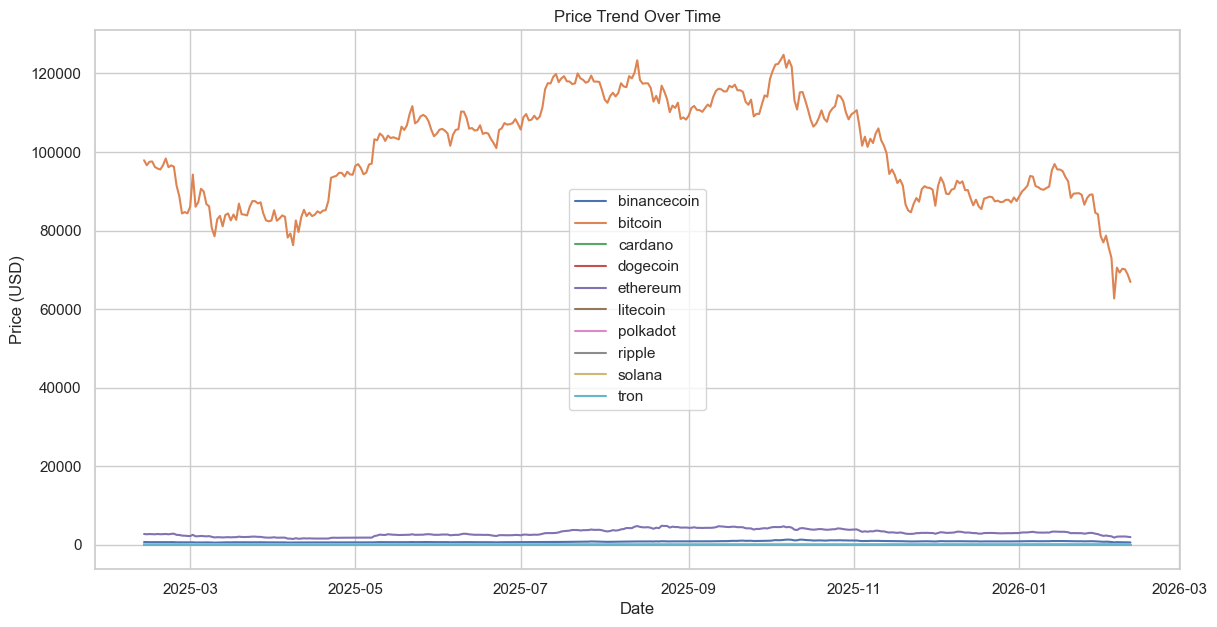

In [3]:
# Plot Price Trend
plt.figure(figsize=(14, 7))
for coin in df['coin_id'].unique():
    subset = df[df['coin_id'] == coin]
    plt.plot(subset['date'], subset['close_price'], label=coin)

plt.title('Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### 2. Cumulative Returns

**What this chart shows:**
This chart shows the growth of a hypothetical $1 investment made at the start of the period for each coin. It normalizes the starting point so all coins begin at 0% (or 1.0).

**Why it is important:**
Comparing raw prices is misleading because Bitcoin costs thousands while Dogecoin costs cents. Cumulative returns allow for a fair "apples-to-apples" comparison of investment performance.

**What an investor can learn:**
You can instantly see which coin would have generated the most profit (or loss) over the period, regardless of its unit price. It highlights the winners and losers in terms of percentage growth.

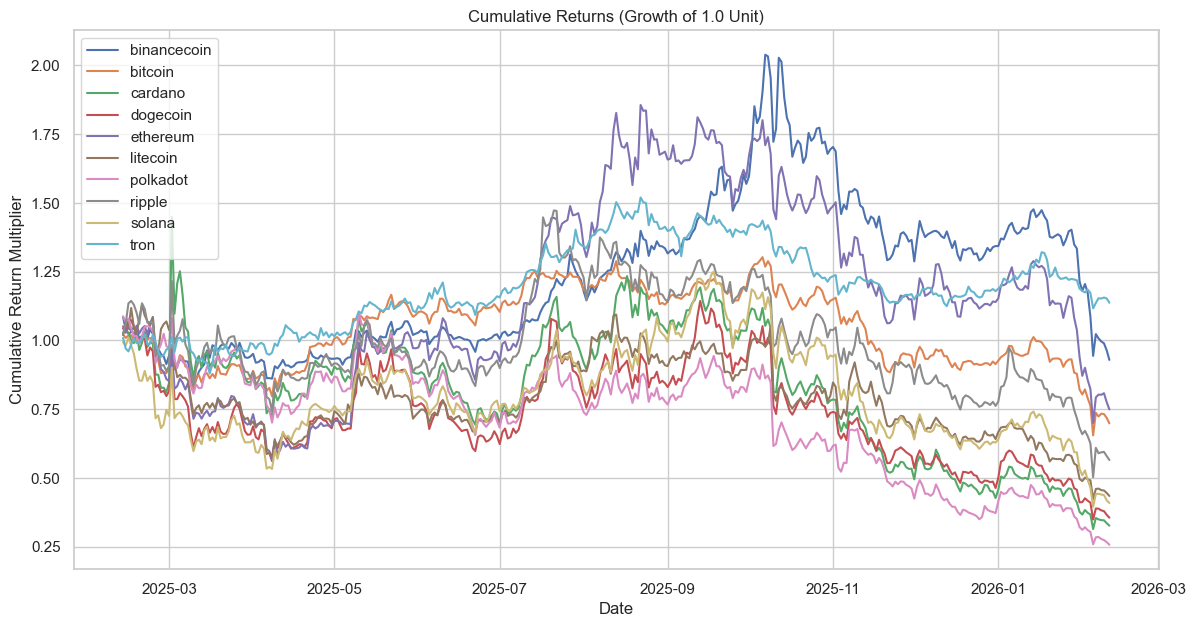

In [4]:
# Calculate Cumulative Returns
df['cumulative_return'] = df.groupby('coin_id')['daily_return'].transform(lambda x: (1 + x).cumprod())

# Plot Cumulative Returns
plt.figure(figsize=(14, 7))
for coin in df['coin_id'].unique():
    subset = df[df['coin_id'] == coin]
    plt.plot(subset['date'], subset['cumulative_return'], label=coin)

plt.title('Cumulative Returns (Growth of 1.0 Unit)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return Multiplier')
plt.legend()
plt.show()

### 3. Daily Return Distribution

**What this chart shows:**
This histogram displays how frequently specific daily returns occur. Most days have small returns (near 0), while tails show extreme gains or losses.

**Why it is important:**
It visualizes the "personality" of the asset. A wide, flat distribution means the coin often experiences wild price swings. A narrow, tall peak means the coin is usually stable.

**What an investor can learn:**
You can assess the likelihood of extreme days. If a coin has a "fat tail" on the left, it means it is prone to significant crashes, representing higher risk.

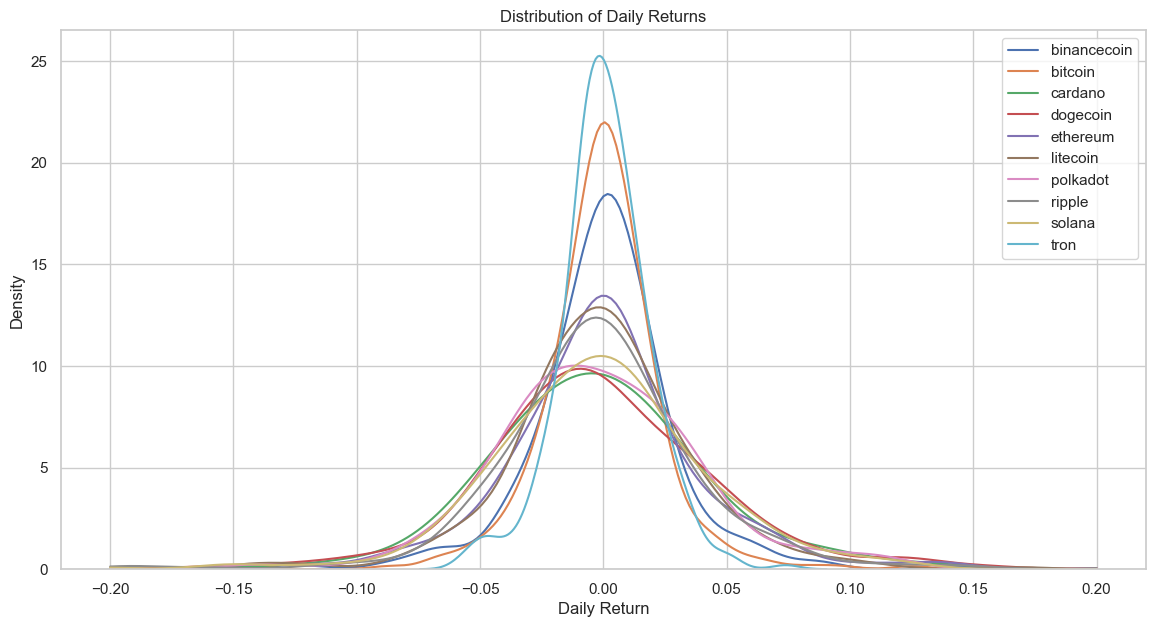

In [5]:
# Plot Daily Return Distribution
plt.figure(figsize=(14, 7))
for coin in df['coin_id'].unique():
    subset = df[df['coin_id'] == coin]
    sns.kdeplot(subset['daily_return'], label=coin, fill=False, clip=(-0.2, 0.2))

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.show()

### 4. Volatility Comparison

**What this chart shows:**
This bar chart compares the standard deviation of daily returns for each coin. Standard deviation is the most common measure of volatility.

**Why it is important:**
It quantifies risk into a single number for each asset. Higher bars indicate assets that move more unpredictably.

**What an investor can learn:**
You can quickly identify the riskiest assets uniquely. Investors typically demand higher potential returns for holding highly volatile assets.

C:\Users\Asus\AppData\Local\Temp\ipykernel_22340\1584705492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volatility.index, y=volatility.values, palette='viridis')


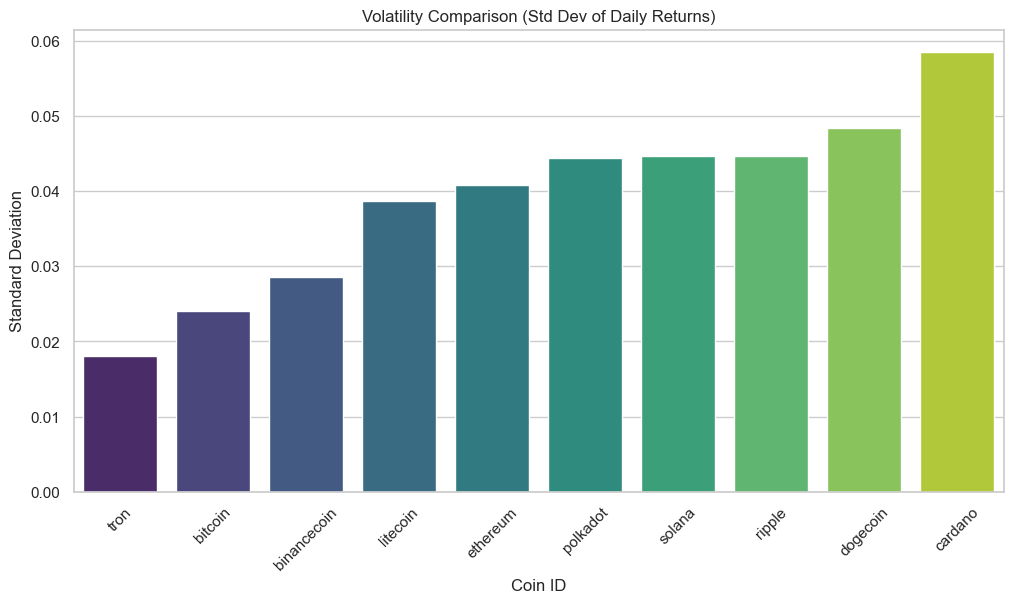

In [6]:
# Calculate Volatility (Standard Deviation)
volatility = df.groupby('coin_id')['daily_return'].std().sort_values()

# Plot Volatility
plt.figure(figsize=(12, 6))
sns.barplot(x=volatility.index, y=volatility.values, palette='viridis')
plt.title('Volatility Comparison (Std Dev of Daily Returns)')
plt.xlabel('Coin ID')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=45)
plt.show()

### 5. Risk vs. Return Scatter Plot

**What this chart shows:**
This scatter plot places each coin on a map where the X-axis is Risk (Volatility) and the Y-axis is Return (Average Daily Return).

**Why it is important:**
This is the fundamental trade-off in finance. Ideally, you want assets in the top-left (High Return, Low Risk). Assets in the bottom-right (Low Return, High Risk) are generally undesirable.

**What an investor can learn:**
It helps in portfolio construction. You can see if you are being adequately compensated (with higher returns) for the extra risk you are taking by holding a volatile coin.

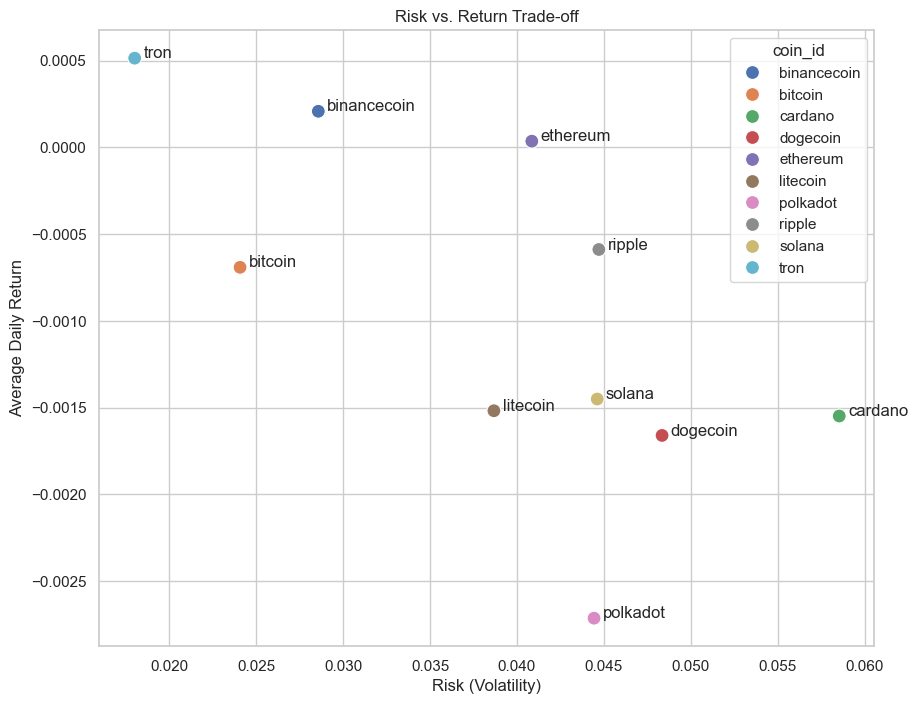

In [7]:
# Calculate Mean Return and Volatility
summary_stats = df.groupby('coin_id')['daily_return'].agg(['mean', 'std']).reset_index()
summary_stats.columns = ['coin_id', 'mean_return', 'volatility']

# Plot Risk vs Return
plt.figure(figsize=(10, 8))
sns.scatterplot(data=summary_stats, x='volatility', y='mean_return', s=100, hue='coin_id')

# Annotate points
for i, row in summary_stats.iterrows():
    plt.text(row['volatility'] + 0.0005, row['mean_return'], row['coin_id'])

plt.title('Risk vs. Return Trade-off')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Average Daily Return')
plt.grid(True)
plt.show()

## Final Summary

Based on the Exploratory Data Analysis above:

1.  **Which coins appear most volatile?**
    *   (Observe the "Volatility Comparison" chart. Typically, smaller cap coins or meme coins like Dogecoin show higher bars.)

2.  **Which coins appear relatively stable?**
    *   (Observe the lowest bars in the volatility chart. Often, larger coins like Bitcoin or stablecoins are on the lower end.)

3.  **Which coins show high return but high risk?**
    *   (Look at the top-right quadrant of the Scatter Plot. These are the aggressive growth plays.)

**Why EDA is important before investing:**
Exploratory Data Analysis separates hype from reality. It allows investors to quantify exactly how much an asset moves (risk) and whether its historical growth (return) justifies that stress. Instead of guessing, EDA provides a data-driven foundation for building a balanced portfolio.